In [1]:
import json
import joblib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

In [2]:
MODELS = [
    {"name": "bino",                "display": "Binocular",        "inverted": True},
    {"name": "fd",                  "display": "FastDetect",       "inverted": False},
    {"name": "gec",                 "display": "GEC score",        "inverted": False},
    {"name": "xlmroberta_ms",       "display": "MS-based TC",      "inverted": False},
    {"name": "osmdet",              "display": "OSM-Det",          "inverted": False},
    {"name": "lfc",                 "display": "LFC",              "inverted": False},
    {"name": "mbert",               "display": "TC (mBERT)",       "inverted": False},
    {"name": "xlmroberta",          "display": "TC (RoBERTa)",     "inverted": False},
    {"name": "gemma3_1b",          "display":  "TC (Gemma3)",      "inverted": False},
    {"name": "mbert_extended",      "display": "TC+ (mBERT)",      "inverted": False},
    {"name": "xlmroberta_extended", "display": "TC+ (RoBERTa)",    "inverted": False},
    {"name": "gemma3_1b_extended", "display":  "TC+ (Gemma3)",     "inverted": False},

]

EXTERNAL_EVAL_NAMES = {
    "bino",
    "fd",
    "gec",
    "xlmroberta_ms",
    "osmdet",
    "lfc",
    "mbert",
    "xlmroberta",
    "gemma3_1b",
    "mbert_extended",
    "xlmroberta_extended",
    "gemma3_1b_extended",
}

_SCORES = "../../scores"

SCORE_FILES_OUR = {
    "bino":                ("02_binoculars/train_val_bino_scores.parquet",       "02_binoculars/test_bino_scores.parquet",            "parquet", "bino_real", "bino_generated"),
    "fd":                  ("03_fastdetectgpt/train_val_fd_scores.parquet",      "03_fastdetectgpt/test_fd_scores.parquet",           "parquet", "fd_real",   "fd_generated"),
    "gec":                 ("01_gecscore/gec_rouge2_scores_train_val.pkl",       "01_gecscore/gec_rouge2_scores_test.pkl",            "joblib",  None,        None),
    "lfc":                 ("06_lfc/lfc_our_val_scores.data",                    "06_lfc/lfc_our_test_scores.data",                   "joblib",  None,        None),
    "mbert":               (f"{_SCORES}/mbert_val_scores.joblib",               f"{_SCORES}/mbert_test_scores.joblib",                "joblib",  None,        None),
    "xlmroberta":          (f"{_SCORES}/xlmroberta_val_scores.joblib",          f"{_SCORES}/xlmroberta_test_scores.joblib",           "joblib",  None,        None),
    "mbert_extended":      (f"{_SCORES}/mbert_extended_val_scores.joblib",      f"{_SCORES}/mbert_extended_test_scores.joblib",       "joblib",  None,        None),
    "xlmroberta_extended": (f"{_SCORES}/xlmroberta_extended_val_scores.joblib", f"{_SCORES}/xlmroberta_extended_test_scores.joblib",  "joblib",  None,        None),
    "xlmroberta_ms":       (f"{_SCORES}/xlmroberta_ms_val_scores.joblib",       f"{_SCORES}/xlmroberta_ms_test_scores.joblib",        "joblib",  None,        None),
    "osmdet":              (f"{_SCORES}/osmdet_val_scores.joblib",              f"{_SCORES}/osmdet_test_scores.joblib",               "joblib",  None,        None),
    "gemma3_1b":           (f"{_SCORES}/gemma3_1b_val_scores.joblib",           f"{_SCORES}/gemma3_1b_test_scores.joblib",            "joblib", None,         None,),
    "gemma3_1b_extended":  (f"{_SCORES}/gemma3_1b_extended_val_scores.joblib",  f"{_SCORES}/gemma3_1b_extended_test_scores.joblib",   "joblib", None,         None,),
}

SCORE_FILES_EXTERNAL = {
    "bino": {
        "multisocial": ("02_binoculars/multisocial_bino_scores.parquet", "parquet", "bino_score"),
        "aigtbench":   ("02_binoculars/AIGTBench_bino_scores.parquet",   "parquet", "bino_score"),
        "fox8":        ("02_binoculars/fox8_bino_scores.parquet",        "parquet", "bino_score"),
    },
    "fd": {
        "multisocial": ("02_binoculars/multisocial_bino_scores.parquet",  "parquet", "bino_score"),  # just a placeholder (not used in the paper)
        "aigtbench":   ("02_binoculars/AIGTBench_bino_scores.parquet",   "parquet", "bino_score"), # just a placeholder (not used in the paper)
        "fox8":        ("03_fastdetectgpt/fox8_fd_scores.parquet",    "parquet", "fd_score"),
    },
    "gec": {
        "multisocial": ("02_binoculars/multisocial_bino_scores.parquet",  "parquet", "bino_score"),  # just a placeholder (not used in the paper)
        "aigtbench":   ("02_binoculars/AIGTBench_bino_scores.parquet",   "parquet", "bino_score"), # just a placeholder (not used in the paper)
        "fox8":        ("01_gecscore/gec_rouge2_scores_fox8.pkl",    "joblib", None),
    },
    "lfc": {
        "multisocial": ("06_lfc/lfc_ms_test_scores.data",          "joblib", None),
        "aigtbench":   ("06_lfc/lfc_AIGTBench_test_scores.data",   "joblib", None),
        "fox8":        ("06_lfc/lfc_fox8_23_scores.data",          "joblib", None),
    },
    "mbert": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_mbert"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_mbert"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_mbert"),
    },
    "xlmroberta": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_xlmroberta"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_xlmroberta"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_xlmroberta"),
    },
    "mbert_extended": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_mbert_extended"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_mbert_extended"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_mbert_extended"),
    },
    "xlmroberta_extended": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_xlmroberta_extended"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_xlmroberta_extended"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_xlmroberta_extended"),
    },
    "xlmroberta_ms": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_xlmroberta_ms"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_xlmroberta_ms"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_xlmroberta_ms"),
    },
    "osmdet": {
        "multisocial": (f"{_SCORES}/multisocial_scores_osmdet.parquet", "parquet", "score_osmdet"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores_osmdet.parquet",   "parquet", "score_osmdet"),
        "fox8":        (f"{_SCORES}/fox8_scores_osmdet.parquet",        "parquet", "score_osmdet"),
    },
    "gemma3_1b": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_gemma3_1b"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_gemma3_1b"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_gemma3_1b"),
    },
    "gemma3_1b_extended": {
        "multisocial": (f"{_SCORES}/multisocial_scores.parquet", "parquet", "score_gemma3_1b_extended"),
        "aigtbench":   (f"{_SCORES}/aigtbench_scores.parquet",   "parquet", "score_gemma3_1b_extended"),
        "fox8":        (f"{_SCORES}/fox8_scores.parquet",        "parquet", "score_gemma3_1b_extended"),
    },
}

DATA_DIR         = "../../data"
TRAIN_PATH       = f"{DATA_DIR}/train_data.parquet"
TEST_PATH        = f"{DATA_DIR}/test_data.parquet"
MULTISOCIAL_PATH = f"{DATA_DIR}/external_data/multisocial/multisocial_anonymized.csv"
AIGTBENCH_PATH   = f"{DATA_DIR}/external_data/AIGTBench"
FOX8_PATH        = f"{DATA_DIR}/external_data/fox8_23_dataset.ndjson"
AIGTBENCH_PLATFORM = "reddit"  # set to None to keep all platforms

N_BOOTSTRAP = 1000
N_SAMPLE = 10000
TEXT_LEN_BINS   = [0, 50, 150, float("inf")]
TEXT_LEN_LABELS = ["0-50", "50-150", "150+"]
# Texts-per-user experiment
TPU_NS    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 100, 200]
TPU_NITER = 100

In [3]:
def _load_pair_dict(path, fmt, real_col, gen_col):
    if fmt == "parquet":
        df = pd.read_parquet(path)
        return {
            (r["model"], r["pipeline"], r["user_id"], r["thread_id"]): (r[real_col], r[gen_col])
            for _, r in df.iterrows()
        }
    return joblib.load(path)


def assign_pair_scores(df, scores, name):
    key = lambda r: (r["model"], r["pipeline"], r["user_id"], r["thread_id"])
    df[f"{name}_real"] = df.apply(lambda r: scores[key(r)][0], axis=1)
    df[f"{name}_gen"]  = df.apply(lambda r: scores[key(r)][1], axis=1)


def assign_external_scores(df, name, path, fmt, score_col=None, fillna=None):
    if fmt == "parquet":
        scores = pd.read_parquet(path)[score_col]
    else:
        score_dict = joblib.load(path)
        scores = df.index.map(score_dict)
    if fillna is not None:
        scores = scores.fillna(fillna)
    df[name] = scores

In [4]:
class MetricsCalculator:
    def __init__(self, scores_real, scores_generated, optimal_threshold=None, inverted=False):
        self.scores_real      = np.array(scores_real)
        self.scores_generated = np.array(scores_generated)

        if inverted:
            self.scores_real      = self.scores_real      * -1
            self.scores_generated = self.scores_generated * -1

        self.y_score = np.array(
            [v if not pd.isna(v) else 0 for v in self.scores_generated] +
            [v if not pd.isna(v) else 0 for v in self.scores_real]
        )
        self.y_true = np.array([1] * len(self.scores_generated) + [0] * len(self.scores_real))

        self.optimal_threshold = (
            optimal_threshold if optimal_threshold is not None
            else self._compute_optimal_threshold()
        )
        self.auc = roc_auc_score(self.y_true, self.y_score)
        self.f1  = self._compute_f1()

    def _compute_optimal_threshold(self):
        fpr, tpr, thresholds = roc_curve(self.y_true, self.y_score)
        return thresholds[np.argmax(tpr - fpr)]

    def _compute_f1(self):
        y_pred = (self.y_score >= self.optimal_threshold).astype(int)
        return f1_score(self.y_true, y_pred, average="macro")

    def bootstrap_metrics(self, n_bootstrap=N_BOOTSTRAP, sample_size=N_SAMPLE, random_state=42):
        rng = np.random.default_rng(random_state)
        real, gen = np.array(self.scores_real), np.array(self.scores_generated)
        n = sample_size or len(real)
        aucs, f1s = [], []
        for _ in range(n_bootstrap):
            idx     = rng.integers(0, len(real), n)
            m       = MetricsCalculator(real[idx], gen[idx], optimal_threshold=self.optimal_threshold)
            aucs.append(m.auc)
            f1s.append(m.f1)
        return {
            "aucs": {"mean": float(np.mean(aucs)), "2std": float(2 * np.std(aucs, ddof=1))},
            "f1s":  {"mean": float(np.mean(f1s)),  "2std": float(2 * np.std(f1s,  ddof=1))},
        }

In [5]:
class MetricsCalculatorExternal:
    def __init__(self, scores, labels, inverted=False):
        self.y_score = np.array(scores) * (-1 if inverted else 1)
        self.y_true  = np.array(labels)
        self.auc     = roc_auc_score(self.y_true, self.y_score)

    def bootstrap_metrics(self, n_bootstrap=N_BOOTSTRAP, sample_size=N_SAMPLE, random_state=42):
        rng = np.random.default_rng(random_state)
        n   = sample_size or len(self.y_true)
        aucs = []
        for _ in range(n_bootstrap):
            idx = rng.integers(0, len(self.y_true), n)
            m   = MetricsCalculatorExternal(self.y_score[idx], self.y_true[idx])
            aucs.append(m.auc)
        return {"aucs": {"mean": float(np.mean(aucs)), "2std": float(2 * np.std(aucs, ddof=1))}}

In [6]:
def get_metric_str(record):
    return f"{round(record['mean'], 3)}\u00b1{round(record['2std'], 3)}"


def display_table(df):
    display(df)
    print(df.to_latex(index=False))


def compute_overall_metrics(models, train_val, test, n_bootstrap=N_BOOTSTRAP):
    rows = []
    for m in tqdm(models):
        name, display, inv = m["name"], m["display"], m["inverted"]
        val_calc  = MetricsCalculator(train_val[f"{name}_real"], train_val[f"{name}_gen"], inverted=inv)
        test_calc = MetricsCalculator(
            test[f"{name}_real"], test[f"{name}_gen"],
            optimal_threshold=val_calc.optimal_threshold, inverted=inv
        )
        bs = test_calc.bootstrap_metrics(n_bootstrap=n_bootstrap)
        rows.append({"Model": display, "AUC": get_metric_str(bs["aucs"]), "F1 (macro)": get_metric_str(bs["f1s"])})
    return pd.DataFrame(rows)


def compute_sliced_auc(models, train_val, test, slice_col, slices, n_bootstrap=N_BOOTSTRAP):
    rows = []
    for m in tqdm(models):
        name, display, inv = m["name"], m["display"], m["inverted"]
        val_calc = MetricsCalculator(train_val[f"{name}_real"], train_val[f"{name}_gen"], inverted=inv)
        row = {"model_name": display}
        for s in slices:
            mask = test[slice_col] == s
            calc = MetricsCalculator(
                test[mask][f"{name}_real"], test[mask][f"{name}_gen"],
                optimal_threshold=val_calc.optimal_threshold, inverted=inv
            )
            bs = calc.bootstrap_metrics(n_bootstrap=n_bootstrap)
            row[str(s)] = get_metric_str(bs["aucs"])
        rows.append(row)
    return pd.DataFrame(rows)


def compute_language_auc_raw(models, train_val, test, languages):
    rows = []
    for m in tqdm(models):
        name, display, inv = m["name"], m["display"], m["inverted"]
        val_calc = MetricsCalculator(train_val[f"{name}_real"], train_val[f"{name}_gen"], inverted=inv)
        row = {"model_name": display}
        for lang in languages:
            mask = test["real_text_language"] == lang
            calc = MetricsCalculator(
                test[mask][f"{name}_real"], test[mask][f"{name}_gen"],
                optimal_threshold=val_calc.optimal_threshold, inverted=inv
            )
            row[lang] = round(calc.auc, 3)
        rows.append(row)
    df = pd.DataFrame(rows)
    return df


def compute_external_benchmark_metrics(models, datasets, n_bootstrap=N_BOOTSTRAP):
    rows = []
    for m in  tqdm(models):
        name, display, inv = m["name"], m["display"], m["inverted"]
        row = {"model": display}
        for ds_name, (df, label_col) in datasets.items():
            calc = MetricsCalculatorExternal(df[name], df[label_col], inverted=inv)
            bs   = calc.bootstrap_metrics(n_bootstrap=n_bootstrap)
            row[ds_name] = get_metric_str(bs["aucs"])
        rows.append(row)
    return pd.DataFrame(rows)

In [7]:
train    = pd.read_parquet(TRAIN_PATH)
train_val = train[train.is_val == True].copy()
test     = pd.read_parquet(TEST_PATH)

# Pre-compute text length bins used in the length-sliced analysis
test["real_text_len"]     = test.real_text.apply(len)
test["real_text_len_bin"] = pd.cut(test["real_text_len"], bins=TEXT_LEN_BINS, labels=TEXT_LEN_LABELS, right=False)

print(f"Train rows: {len(train):,}  |  Val rows: {len(train_val):,}  |  Test rows: {len(test):,}")
# display(test.real_text_len_bin.value_counts())

Train rows: 192,139  |  Val rows: 9,263  |  Test rows: 71,455


In [8]:
for m in MODELS:
    name = m["name"]
    val_path, test_path, fmt, real_col, gen_col = SCORE_FILES_OUR[name]
    val_scores  = _load_pair_dict(val_path,  fmt, real_col, gen_col)
    test_scores = _load_pair_dict(test_path, fmt, real_col, gen_col)
    assign_pair_scores(train_val, val_scores,  name)
    assign_pair_scores(test,      test_scores, name)
    print(f"  Loaded scores for: {name}")

print("\nAll scores loaded.")

  Loaded scores for: bino
  Loaded scores for: fd
  Loaded scores for: gec
  Loaded scores for: xlmroberta_ms
  Loaded scores for: osmdet
  Loaded scores for: lfc
  Loaded scores for: mbert
  Loaded scores for: xlmroberta
  Loaded scores for: gemma3_1b
  Loaded scores for: mbert_extended
  Loaded scores for: xlmroberta_extended
  Loaded scores for: gemma3_1b_extended

All scores loaded.


## Text-Level Analysis (Our Dataset)

### Overall AUC and F1

In [25]:
overall_df = compute_overall_metrics(MODELS, train_val, test, n_bootstrap=N_BOOTSTRAP)
display_table(overall_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:03<00:00,  5.27s/it]


,Model,AUC,F1 (macro)
0,Binocular,0.665±0.007,0.621±0.006
1,FastDetect,0.681±0.007,0.625±0.006
2,GEC score,0.646±0.007,0.628±0.007
3,MS-based TC,0.7±0.007,0.646±0.006
4,OSM-Det,0.603±0.006,0.564±0.006
5,LFC,0.858±0.005,0.773±0.006
6,TC (mBERT),0.961±0.002,0.893±0.004
7,TC (RoBERTa),0.969±0.002,0.906±0.004
8,TC (Gemma3),0.964±0.002,0.903±0.004
9,TC+ (mBERT),0.959±0.002,0.889±0.004


\begin{tabular}{lll}
\toprule
Model & AUC & F1 (macro) \\
\midrule
Binocular & 0.665±0.007 & 0.621±0.006 \\
FastDetect & 0.681±0.007 & 0.625±0.006 \\
GEC score & 0.646±0.007 & 0.628±0.007 \\
MS-based TC & 0.7±0.007 & 0.646±0.006 \\
OSM-Det & 0.603±0.006 & 0.564±0.006 \\
LFC & 0.858±0.005 & 0.773±0.006 \\
TC (mBERT) & 0.961±0.002 & 0.893±0.004 \\
TC (RoBERTa) & 0.969±0.002 & 0.906±0.004 \\
TC (Gemma3) & 0.964±0.002 & 0.903±0.004 \\
TC+ (mBERT) & 0.959±0.002 & 0.889±0.004 \\
TC+ (RoBERTa) & 0.967±0.002 & 0.902±0.004 \\
TC+ (Gemma3) & 0.969±0.002 & 0.905±0.004 \\
\bottomrule
\end{tabular}



### By LLM

In [26]:
llm_auc_df = compute_sliced_auc(MODELS, train_val, test, "model", ["gemma_small", "qwen"])
display_table(llm_auc_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:06<00:00, 10.53s/it]


,model_name,gemma_small,qwen
0,Binocular,0.727±0.007,0.607±0.007
1,FastDetect,0.737±0.006,0.629±0.007
2,GEC score,0.678±0.007,0.617±0.007
3,MS-based TC,0.812±0.005,0.596±0.007
4,OSM-Det,0.668±0.006,0.541±0.006
5,LFC,0.901±0.004,0.817±0.006
6,TC (mBERT),0.97±0.002,0.952±0.003
7,TC (RoBERTa),0.978±0.002,0.961±0.002
8,TC (Gemma3),0.97±0.002,0.959±0.003
9,TC+ (mBERT),0.97±0.002,0.949±0.003


\begin{tabular}{lll}
\toprule
model_name & gemma_small & qwen \\
\midrule
Binocular & 0.727±0.007 & 0.607±0.007 \\
FastDetect & 0.737±0.006 & 0.629±0.007 \\
GEC score & 0.678±0.007 & 0.617±0.007 \\
MS-based TC & 0.812±0.005 & 0.596±0.007 \\
OSM-Det & 0.668±0.006 & 0.541±0.006 \\
LFC & 0.901±0.004 & 0.817±0.006 \\
TC (mBERT) & 0.97±0.002 & 0.952±0.003 \\
TC (RoBERTa) & 0.978±0.002 & 0.961±0.002 \\
TC (Gemma3) & 0.97±0.002 & 0.959±0.003 \\
TC+ (mBERT) & 0.97±0.002 & 0.949±0.003 \\
TC+ (RoBERTa) & 0.976±0.002 & 0.958±0.003 \\
TC+ (Gemma3) & 0.974±0.002 & 0.964±0.002 \\
\bottomrule
\end{tabular}



### By Pipeline

In [27]:
pipeline_auc_df = compute_sliced_auc(MODELS, train_val, test, "pipeline", ["full", "reduced"])
display_table(pipeline_auc_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:02<00:00, 10.25s/it]


,model_name,full,reduced
0,Binocular,0.65±0.007,0.681±0.007
1,FastDetect,0.669±0.007,0.693±0.007
2,GEC score,0.622±0.007,0.671±0.007
3,MS-based TC,0.656±0.007,0.747±0.007
4,OSM-Det,0.583±0.006,0.624±0.007
5,LFC,0.817±0.006,0.901±0.004
6,TC (mBERT),0.941±0.003,0.981±0.001
7,TC (RoBERTa),0.953±0.003,0.986±0.001
8,TC (Gemma3),0.95±0.003,0.978±0.002
9,TC+ (mBERT),0.939±0.003,0.98±0.002


\begin{tabular}{lll}
\toprule
model_name & full & reduced \\
\midrule
Binocular & 0.65±0.007 & 0.681±0.007 \\
FastDetect & 0.669±0.007 & 0.693±0.007 \\
GEC score & 0.622±0.007 & 0.671±0.007 \\
MS-based TC & 0.656±0.007 & 0.747±0.007 \\
OSM-Det & 0.583±0.006 & 0.624±0.007 \\
LFC & 0.817±0.006 & 0.901±0.004 \\
TC (mBERT) & 0.941±0.003 & 0.981±0.001 \\
TC (RoBERTa) & 0.953±0.003 & 0.986±0.001 \\
TC (Gemma3) & 0.95±0.003 & 0.978±0.002 \\
TC+ (mBERT) & 0.939±0.003 & 0.98±0.002 \\
TC+ (RoBERTa) & 0.95±0.003 & 0.984±0.001 \\
TC+ (Gemma3) & 0.953±0.003 & 0.985±0.001 \\
\bottomrule
\end{tabular}



### By Platform

In [28]:
platform_auc_df = compute_sliced_auc(MODELS, train_val, test, "platform", ["reddit", "telegram"])
display_table(platform_auc_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:58<00:00,  9.89s/it]


,model_name,reddit,telegram
0,Binocular,0.655±0.007,0.679±0.006
1,FastDetect,0.672±0.007,0.694±0.007
2,GEC score,0.64±0.007,0.654±0.007
3,MS-based TC,0.688±0.007,0.723±0.006
4,OSM-Det,0.581±0.007,0.636±0.006
5,LFC,0.877±0.005,0.835±0.006
6,TC (mBERT),0.974±0.002,0.942±0.003
7,TC (RoBERTa),0.98±0.002,0.954±0.003
8,TC (Gemma3),0.974±0.002,0.95±0.003
9,TC+ (mBERT),0.971±0.002,0.941±0.003


\begin{tabular}{lll}
\toprule
model_name & reddit & telegram \\
\midrule
Binocular & 0.655±0.007 & 0.679±0.006 \\
FastDetect & 0.672±0.007 & 0.694±0.007 \\
GEC score & 0.64±0.007 & 0.654±0.007 \\
MS-based TC & 0.688±0.007 & 0.723±0.006 \\
OSM-Det & 0.581±0.007 & 0.636±0.006 \\
LFC & 0.877±0.005 & 0.835±0.006 \\
TC (mBERT) & 0.974±0.002 & 0.942±0.003 \\
TC (RoBERTa) & 0.98±0.002 & 0.954±0.003 \\
TC (Gemma3) & 0.974±0.002 & 0.95±0.003 \\
TC+ (mBERT) & 0.971±0.002 & 0.941±0.003 \\
TC+ (RoBERTa) & 0.977±0.002 & 0.952±0.003 \\
TC+ (Gemma3) & 0.979±0.002 & 0.954±0.003 \\
\bottomrule
\end{tabular}



### By Text Length

In [29]:
length_auc_df = compute_sliced_auc(MODELS, train_val, test, "real_text_len_bin", TEXT_LEN_LABELS)
display_table(length_auc_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [02:58<00:00, 14.91s/it]


,model_name,0-50,50-150,150+
0,Binocular,0.615±0.007,0.671±0.007,0.78±0.006
1,FastDetect,0.62±0.007,0.673±0.007,0.781±0.006
2,GEC score,0.593±0.007,0.663±0.007,0.722±0.007
3,MS-based TC,0.632±0.007,0.686±0.007,0.786±0.006
4,OSM-Det,0.577±0.006,0.643±0.006,0.591±0.007
5,LFC,0.772±0.006,0.854±0.005,0.926±0.004
6,TC (mBERT),0.907±0.004,0.967±0.002,0.987±0.001
7,TC (RoBERTa),0.92±0.004,0.976±0.002,0.99±0.001
8,TC (Gemma3),0.922±0.004,0.966±0.002,0.987±0.002
9,TC+ (mBERT),0.908±0.004,0.966±0.002,0.986±0.001


\begin{tabular}{llll}
\toprule
model_name & 0-50 & 50-150 & 150+ \\
\midrule
Binocular & 0.615±0.007 & 0.671±0.007 & 0.78±0.006 \\
FastDetect & 0.62±0.007 & 0.673±0.007 & 0.781±0.006 \\
GEC score & 0.593±0.007 & 0.663±0.007 & 0.722±0.007 \\
MS-based TC & 0.632±0.007 & 0.686±0.007 & 0.786±0.006 \\
OSM-Det & 0.577±0.006 & 0.643±0.006 & 0.591±0.007 \\
LFC & 0.772±0.006 & 0.854±0.005 & 0.926±0.004 \\
TC (mBERT) & 0.907±0.004 & 0.967±0.002 & 0.987±0.001 \\
TC (RoBERTa) & 0.92±0.004 & 0.976±0.002 & 0.99±0.001 \\
TC (Gemma3) & 0.922±0.004 & 0.966±0.002 & 0.987±0.002 \\
TC+ (mBERT) & 0.908±0.004 & 0.966±0.002 & 0.986±0.001 \\
TC+ (RoBERTa) & 0.921±0.004 & 0.974±0.002 & 0.988±0.001 \\
TC+ (Gemma3) & 0.923±0.004 & 0.974±0.002 & 0.991±0.001 \\
\bottomrule
\end{tabular}



### By Language

In [53]:
languages = np.sort(test.real_text_language.unique())

lang_auc_raw_df = compute_language_auc_raw(MODELS, train_val, test, languages)
display(
    lang_auc_raw_df.style
    .format({c: "{:.3f}" for c in lang_auc_raw_df.select_dtypes("number").columns})
    .background_gradient(axis=0, cmap="RdYlGn")
)

cc = lang_auc_raw_df.columns[1:]
for c in cc:
    lang_auc_raw_df[c] = lang_auc_raw_df[c].apply(str)
print(lang_auc_raw_df.to_latex(index=False))

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:01<00:00, 10.03it/s]


,model_name,AR,BG,CA,DE,EL,EN,ES,FA,FR,IT,JA,KO,PL,PT,RU,UK,ZH
0,Binocular,0.721,0.702,0.656,0.683,0.691,0.608,0.714,0.622,0.714,0.673,0.553,0.698,0.667,0.658,0.736,0.710,0.531
1,FastDetect,0.734,0.720,0.681,0.699,0.716,0.623,0.728,0.634,0.724,0.695,0.600,0.693,0.688,0.676,0.749,0.726,0.565
2,GEC score,0.651,0.702,0.695,0.695,0.675,0.631,0.682,0.589,0.706,0.677,0.407,0.739,0.653,0.640,0.620,0.642,0.443
3,MS-based TC,0.780,0.712,0.733,0.767,0.756,0.655,0.712,0.760,0.745,0.708,0.589,0.760,0.712,0.691,0.683,0.752,0.440
4,OSM-Det,0.688,0.581,0.506,0.595,0.639,0.705,0.662,0.657,0.579,0.621,0.286,0.493,0.588,0.604,0.576,0.633,0.540
5,LFC,0.832,0.818,0.859,0.866,0.810,0.909,0.837,0.825,0.880,0.876,0.837,0.760,0.836,0.859,0.831,0.844,0.716
6,TC (mBERT),0.928,0.965,0.964,0.975,0.938,0.977,0.946,0.906,0.977,0.971,0.940,0.907,0.953,0.966,0.970,0.960,0.703
7,TC (RoBERTa),0.946,0.978,0.978,0.980,0.958,0.978,0.957,0.932,0.984,0.979,0.941,0.951,0.961,0.973,0.976,0.970,0.733
8,TC (Gemma3),0.951,0.974,0.968,0.973,0.959,0.969,0.956,0.921,0.974,0.973,0.950,0.973,0.953,0.968,0.973,0.971,0.725
9,TC+ (mBERT),0.935,0.960,0.960,0.972,0.936,0.973,0.950,0.909,0.973,0.967,0.933,0.851,0.953,0.963,0.968,0.958,0.720


\begin{tabular}{llllllllllllllllll}
\toprule
model_name & AR & BG & CA & DE & EL & EN & ES & FA & FR & IT & JA & KO & PL & PT & RU & UK & ZH \\
\midrule
Binocular & 0.721 & 0.702 & 0.656 & 0.683 & 0.691 & 0.608 & 0.714 & 0.622 & 0.714 & 0.673 & 0.553 & 0.698 & 0.667 & 0.658 & 0.736 & 0.71 & 0.531 \\
FastDetect & 0.734 & 0.72 & 0.681 & 0.699 & 0.716 & 0.623 & 0.728 & 0.634 & 0.724 & 0.695 & 0.6 & 0.693 & 0.688 & 0.676 & 0.749 & 0.726 & 0.565 \\
GEC score & 0.651 & 0.702 & 0.695 & 0.695 & 0.675 & 0.631 & 0.682 & 0.589 & 0.706 & 0.677 & 0.407 & 0.739 & 0.653 & 0.64 & 0.62 & 0.642 & 0.443 \\
MS-based TC & 0.78 & 0.712 & 0.733 & 0.767 & 0.756 & 0.655 & 0.712 & 0.76 & 0.745 & 0.708 & 0.589 & 0.76 & 0.712 & 0.691 & 0.683 & 0.752 & 0.44 \\
OSM-Det & 0.688 & 0.581 & 0.506 & 0.595 & 0.639 & 0.705 & 0.662 & 0.657 & 0.579 & 0.621 & 0.286 & 0.493 & 0.588 & 0.604 & 0.576 & 0.633 & 0.54 \\
LFC & 0.832 & 0.818 & 0.859 & 0.866 & 0.81 & 0.909 & 0.837 & 0.825 & 0.88 & 0.876 & 0.837 & 0.76 & 0.836 & 0.859

## External Benchmarks

In [9]:
# Multisocial
multisocial = pd.read_csv(MULTISOCIAL_PATH)
multisocial = multisocial[multisocial.split == "test"].copy()
print(f"Multisocial: {len(multisocial):,} rows")

# AIGTBench
aigtbench = pd.read_parquet(AIGTBENCH_PATH)
if AIGTBENCH_PLATFORM:
    aigtbench = aigtbench[aigtbench.social_media_platform == AIGTBENCH_PLATFORM].copy()
print(f"AIGTBench:   {len(aigtbench):,} rows  (platform={AIGTBENCH_PLATFORM!r})")

# Fox8-23
with open(FOX8_PATH, "r", encoding="utf-8") as f:
    fox8_raw = [json.loads(line) for line in f]

fox8_rows = []
for sample in tqdm(fox8_raw, desc="Parsing Fox8-23"):
    label   = 0 if sample["label"] == "human" else 1
    user_id = sample["user_id"]
    for tweet in sample["user_tweets"]:
        fox8_rows.append({"text": tweet["text"], "user_id": user_id, "label": label})
fox8 = pd.DataFrame(fox8_rows)
print(f"Fox8-23:     {len(fox8):,} rows  |  {fox8.user_id.nunique():,} users")

Multisocial: 140,888 rows
AIGTBench:   195,836 rows  (platform='reddit')


Parsing Fox8-23: 100%|██████████████████████████████████████████████████████████████████████| 2280/2280 [00:00<00:00, 17923.44it/s]


Fox8-23:     368,028 rows  |  2,279 users


In [10]:
ext_dfs = {"multisocial": multisocial, "aigtbench": aigtbench, "fox8": fox8}

fillna_map = {
    ("fox8", "parquet", "bino"): 0,
    ("fox8", "parquet", "fd"): 0,
    ("fox8", "joblib", "gec"): 0,
}

for name, ds_files in SCORE_FILES_EXTERNAL.items():
    for ds_key, (path, fmt, score_col) in ds_files.items():
        fillna = fillna_map.get((ds_key, fmt, name))
        assign_external_scores(ext_dfs[ds_key], name, path, fmt, score_col, fillna=fillna)
    print(f"  Loaded external scores for: {name}")

print("\nAll external scores loaded.")

  Loaded external scores for: bino
  Loaded external scores for: fd
  Loaded external scores for: gec
  Loaded external scores for: lfc
  Loaded external scores for: mbert
  Loaded external scores for: xlmroberta
  Loaded external scores for: mbert_extended
  Loaded external scores for: xlmroberta_extended
  Loaded external scores for: xlmroberta_ms
  Loaded external scores for: osmdet
  Loaded external scores for: gemma3_1b
  Loaded external scores for: gemma3_1b_extended

All external scores loaded.


## Text-Level Analysis (External Benchmarks)

NOTE: FastDetect and GEC score are just a placeholders for MultiSocial and AIGTBench (are not correct). 

In [31]:
external_models = [m for m in MODELS if m["name"] in EXTERNAL_EVAL_NAMES]

external_results_df = compute_external_benchmark_metrics(
    external_models,
    datasets={
        "MultiSocial": (multisocial, "label"),
        "AIGTBench":   (aigtbench,   "label"),
        "Fox8-23":     (fox8,        "label"),
    },
    n_bootstrap=N_BOOTSTRAP,
)
display_table(external_results_df)

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:36<00:00,  3.06s/it]


,model,MultiSocial,AIGTBench,Fox8-23
0,Binocular,0.709±0.015,0.74±0.01,0.55±0.011
1,FastDetect,0.291±0.015,0.26±0.01,0.543±0.011
2,GEC score,0.291±0.015,0.26±0.01,0.593±0.01
3,MS-based TC,0.974±0.004,0.935±0.005,0.582±0.011
4,OSM-Det,0.675±0.015,0.999±0.001,0.62±0.011
5,LFC,0.581±0.017,0.645±0.011,0.602±0.012
6,TC (mBERT),0.492±0.015,0.818±0.008,0.72±0.01
7,TC (RoBERTa),0.461±0.014,0.876±0.007,0.714±0.01
8,TC (Gemma3),0.538±0.016,0.862±0.008,0.722±0.01
9,TC+ (mBERT),0.579±0.014,0.847±0.008,0.726±0.01


\begin{tabular}{llll}
\toprule
model & MultiSocial & AIGTBench & Fox8-23 \\
\midrule
Binocular & 0.709±0.015 & 0.74±0.01 & 0.55±0.011 \\
FastDetect & 0.291±0.015 & 0.26±0.01 & 0.543±0.011 \\
GEC score & 0.291±0.015 & 0.26±0.01 & 0.593±0.01 \\
MS-based TC & 0.974±0.004 & 0.935±0.005 & 0.582±0.011 \\
OSM-Det & 0.675±0.015 & 0.999±0.001 & 0.62±0.011 \\
LFC & 0.581±0.017 & 0.645±0.011 & 0.602±0.012 \\
TC (mBERT) & 0.492±0.015 & 0.818±0.008 & 0.72±0.01 \\
TC (RoBERTa) & 0.461±0.014 & 0.876±0.007 & 0.714±0.01 \\
TC (Gemma3) & 0.538±0.016 & 0.862±0.008 & 0.722±0.01 \\
TC+ (mBERT) & 0.579±0.014 & 0.847±0.008 & 0.726±0.01 \\
TC+ (RoBERTa) & 0.557±0.014 & 0.895±0.006 & 0.725±0.01 \\
TC+ (Gemma3) & 0.593±0.015 & 0.88±0.007 & 0.677±0.011 \\
\bottomrule
\end{tabular}



## User-Level Analysis (Our Dataset)

In [36]:
key_cols       = ["model", "pipeline", "user_id", "platform", "channel"]
score_cols_all = [f"{m['name']}_{s}" for m in MODELS for s in ("real", "gen")]

train_val_agg = train_val.groupby(key_cols)[score_cols_all].mean().reset_index()
test_agg      = test.groupby(key_cols)[score_cols_all].mean().reset_index()

print(f"Val aggregated rows:  {len(train_val_agg):,}")
print(f"Test aggregated rows: {len(test_agg):,}")

Val aggregated rows:  838
Test aggregated rows: 6,940


In [38]:
user_level_df = compute_overall_metrics(MODELS, train_val_agg, test_agg, n_bootstrap=N_BOOTSTRAP)
user_level_df

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:58<00:00,  4.90s/it]


,Model,AUC,F1 (macro)
0,Binocular,0.754±0.005,0.691±0.006
1,FastDetect,0.797±0.005,0.724±0.006
2,GEC score,0.726±0.006,0.682±0.006
3,MS-based TC,0.766±0.006,0.702±0.006
4,OSM-Det,0.626±0.005,0.582±0.005
5,LFC,0.96±0.003,0.904±0.004
6,TC (mBERT),0.991±0.001,0.972±0.002
7,TC (RoBERTa),0.993±0.001,0.979±0.002
8,TC (Gemma3),0.993±0.001,0.978±0.002
9,TC+ (mBERT),0.991±0.001,0.971±0.002


## User-Level Analysis (Fox8-23)

In [39]:
ext_score_names = list(EXTERNAL_EVAL_NAMES)
fox8_agg = fox8.groupby(["user_id", "label"])[ext_score_names].mean().reset_index()

fox8_user_rows = []
for m in external_models:
    name, display, inv = m["name"], m["display"], m["inverted"]
    calc = MetricsCalculatorExternal(fox8_agg[name], fox8_agg["label"], inverted=inv)
    bs   = calc.bootstrap_metrics(n_bootstrap=N_BOOTSTRAP)
    fox8_user_rows.append({"model": display, "Fox8-23 (user-level)": get_metric_str(bs["aucs"])})

fox8_user_df = pd.DataFrame(fox8_user_rows)
fox8_user_df
# display_table(fox8_user_df)

,model,Fox8-23 (user-level)
0,Binocular,0.688±0.011
1,FastDetect,0.672±0.012
2,GEC score,0.811±0.009
3,MS-based TC,0.744±0.011
4,OSM-Det,0.861±0.008
5,LFC,0.907±0.007
6,TC (mBERT),0.989±0.002
7,TC (RoBERTa),0.972±0.004
8,TC (Gemma3),0.941±0.006
9,TC+ (mBERT),0.989±0.002


In [40]:
our_user_rows = []
for m in external_models:
    name, display, inv = m["name"], m["display"], m["inverted"]
    val_calc  = MetricsCalculator(train_val_agg[f"{name}_real"], train_val_agg[f"{name}_gen"], inverted=inv)
    test_calc = MetricsCalculator(
        test_agg[f"{name}_real"], test_agg[f"{name}_gen"],
        optimal_threshold=val_calc.optimal_threshold, inverted=inv
    )
    bs = test_calc.bootstrap_metrics(n_bootstrap=N_BOOTSTRAP)
    our_user_rows.append({"model": display, "auc_bs": bs["aucs"]})

combined_rows = []
for r_our, r_fox in zip(our_user_rows, fox8_user_rows):
    combined_rows.append({
        "Model":    r_our["model"],
        "Our Data": get_metric_str(r_our["auc_bs"]),
        "Fox8-23":  r_fox["Fox8-23 (user-level)"],
    })

combined_df = pd.DataFrame(combined_rows)
print(combined_df.to_latex(index=False))
combined_df

\begin{tabular}{lll}
\toprule
Model & Our Data & Fox8-23 \\
\midrule
Binocular & 0.754±0.005 & 0.688±0.011 \\
FastDetect & 0.797±0.005 & 0.672±0.012 \\
GEC score & 0.726±0.006 & 0.811±0.009 \\
MS-based TC & 0.766±0.006 & 0.744±0.011 \\
OSM-Det & 0.626±0.005 & 0.861±0.008 \\
LFC & 0.96±0.003 & 0.907±0.007 \\
TC (mBERT) & 0.991±0.001 & 0.989±0.002 \\
TC (RoBERTa) & 0.993±0.001 & 0.972±0.004 \\
TC (Gemma3) & 0.993±0.001 & 0.941±0.006 \\
TC+ (mBERT) & 0.991±0.001 & 0.989±0.002 \\
TC+ (RoBERTa) & 0.992±0.001 & 0.982±0.003 \\
TC+ (Gemma3) & 0.993±0.001 & 0.936±0.006 \\
\bottomrule
\end{tabular}



,Model,Our Data,Fox8-23
0,Binocular,0.754±0.005,0.688±0.011
1,FastDetect,0.797±0.005,0.672±0.012
2,GEC score,0.726±0.006,0.811±0.009
3,MS-based TC,0.766±0.006,0.744±0.011
4,OSM-Det,0.626±0.005,0.861±0.008
5,LFC,0.96±0.003,0.907±0.007
6,TC (mBERT),0.991±0.001,0.989±0.002
7,TC (RoBERTa),0.993±0.001,0.972±0.004
8,TC (Gemma3),0.993±0.001,0.941±0.006
9,TC+ (mBERT),0.991±0.001,0.989±0.002


## Texts-per-User Experiment (Fox8-23)
Measures how AUC changes as more tweets per user are aggregated.

In [61]:
all_metrics = []

for n in tqdm(TPU_NS, desc="n tweets"):
    for i in range(TPU_NITER):
        fox8_sampled = (
            fox8.groupby(["user_id", "label"])
            .apply(lambda x: x.sample(n=min(len(x), n), replace=False, random_state=i))
            .reset_index(drop=True)
        )
        fox8_sampled_agg = fox8_sampled.groupby(["user_id", "label"])[ext_score_names].mean().reset_index()

        for m in external_models:
            name, inv = m["name"], m["inverted"]
            scores = fox8_sampled_agg[name] * (-1 if inv else 1)
            auc = roc_auc_score(fox8_sampled_agg["label"].astype(int), scores)
            all_metrics.append((auc, name, n))

all_metrics_df = pd.DataFrame(all_metrics, columns=["value", "model", "n"])

n tweets: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [17:44<00:00, 66.55s/it]


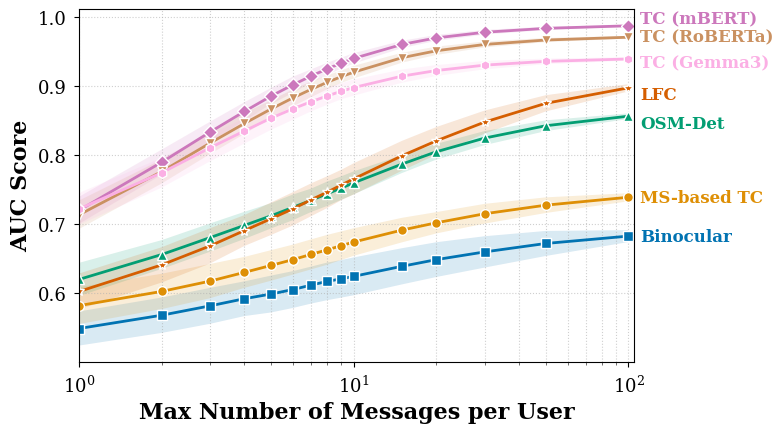

In [71]:
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.family": "serif", "font.size": 12,
    "axes.titlesize": 12, "axes.labelsize": 12,
    "legend.fontsize": 10, "xtick.labelsize": 12,
    "ytick.labelsize": 12, "lines.linewidth": 2.0,
})

display_names = {m["name"]: m["display"] for m in external_models}
marker_types  = ['s', 'o', '^', '*', 'D', 'v', 'h', 'p', 'H', '8', '<', '>', '+', 'x']
markers  = {m["name"]: t for m, t in zip(external_models, marker_types)}
colors   = sns.color_palette("colorblind", len(external_models))
name_seq = [m["name"] for m in external_models]

offsets = {"TC (mBERT)": 0.01, "TC (RoBERTa)": -0.00, "TC (Gemma3)": -0.005, "LFC": -0.01, "OSM-Det": -0.01}

plot_df = all_metrics_df[all_metrics_df["n"] <= 100]

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, name in enumerate(name_seq):
    if name in ["mbert_extended", "xlmroberta_extended", "gemma3_1b_extended"]: # excluded from paper
        continue
    subset = plot_df[plot_df["model"] == name]
    stats  = subset.groupby("n")["value"].agg(["mean", "std"]).sort_index()
    x, y, y_err = stats.index.values, stats["mean"].values, 2 * stats["std"].values

    ax.fill_between(x, y - y_err, y + y_err, color=colors[i], alpha=0.15, edgecolor=None)
    ax.plot(x, y, marker=markers[name], markersize=7,
            markeredgecolor="white", markeredgewidth=1, color=colors[i], label=display_names[name])

    last_n  = plot_df[plot_df["model"] == name].groupby("n")["value"].mean().index[-1]
    last_y  = plot_df[plot_df["model"] == name].groupby("n")["value"].mean().iloc[-1]
    y_pos   = last_y + offsets.get(display_names[name], 0)
    ax.text(last_n * 1.1, y_pos, display_names[name],
            color=colors[i], va="center", fontweight="bold", fontsize=12)

ax.set_xscale("log")
ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.set_xlabel("Max Number of Messages per User", fontweight="bold", fontsize=16)
ax.set_ylabel("AUC Score", fontweight="bold", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.set_xlim(1, 105)
plt.tight_layout()
plt.savefig("bot_detection_with_ci.png", dpi=600, bbox_inches="tight")
plt.show()

In [63]:
subset = plot_df[plot_df["model"] == "mbert"]
stats  = subset.groupby("n")["value"].agg(["mean", "std"]).sort_index()
stats

,mean,std
n,,
1,0.720314,0.009799
2,0.790087,0.009122
3,0.833826,0.007472
4,0.863634,0.006676
5,0.885875,0.005893
6,0.902145,0.005877
7,0.914987,0.004820
8,0.925237,0.004433
9,0.933655,0.003932
